# Notebook — Teste do módulo `normal_gravity.py`

Este notebook testa o módulo:

```python
geodesy/normal_gravity.py
```

e inclui, nas últimas células, mapas globais com **Cartopy** em **contorno preenchido (`contourf`)** para:

- gravidade normal;
- gravidade teórica calculada;
- diferença entre ambas.

A malha global usa passo de **0.5 grau**.


In [1]:
# ============================================================
# 0. CONFIGURAÇÃO INICIAL
# ============================================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
    print("Pasta geodesy encontrada no diretório atual.")
else:
    print("Atenção: a pasta geodesy não foi encontrada no diretório atual.")
    print("Coloque este notebook no mesmo diretório da pasta geodesy/.")

import geodesy
from geodesy import normal_gravity
from geodesy import constants
from geodesy import ellipsoid

print("Versão do pacote geodesy:", geodesy.__version__)

import cartopy.crs as ccrs
import cartopy.feature as cfeature


Pasta geodesy encontrada no diretório atual.
Versão do pacote geodesy: 0.1.0


## 1. Gravidade normal pela fórmula de Somigliana


In [2]:
# ============================================================
# 1. GRAVIDADE NORMAL NO ELIPSOIDE
# ============================================================

latitudes = np.array([-90, -60, -30, 0, 30, 60, 90], dtype=float)
gamma = normal_gravity.normal_gravity_somigliana(latitudes)

print("Latitude (graus) | Gravidade normal (m/s²)")
print("-" * 45)
for la, ga in zip(latitudes, gamma):
    print(f"{la:8.1f}        | {ga:.10f}")

print("\nEquador:", normal_gravity.normal_gravity_somigliana(0.0))
print("Polo:", normal_gravity.normal_gravity_somigliana(90.0))


Latitude (graus) | Gravidade normal (m/s²)
---------------------------------------------
   -90.0        | 9.8321849379
   -60.0        | 9.8191769531
   -30.0        | 9.7932472692
     0.0        | 9.7803253359
    30.0        | 9.7932472692
    60.0        | 9.8191769531
    90.0        | 9.8321849379

Equador: 9.7803253359
Polo: 9.832184937859015


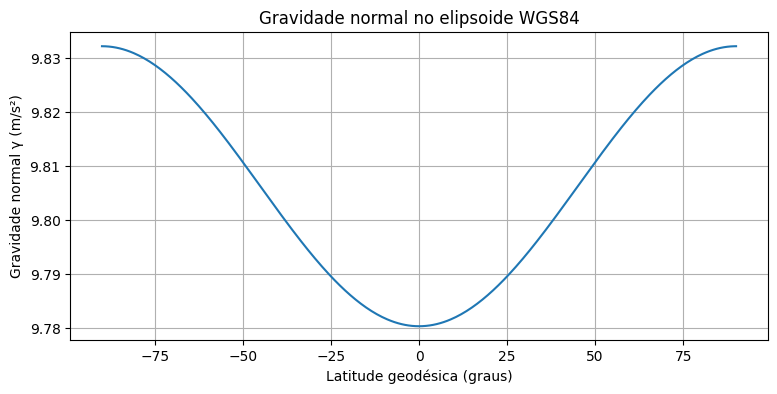

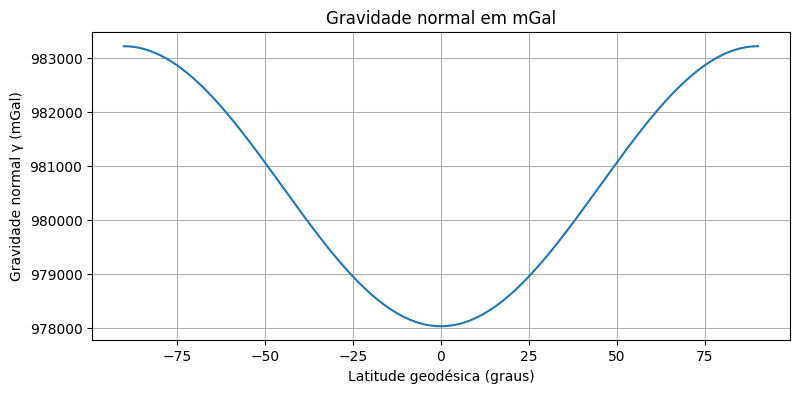

In [3]:
lat = np.linspace(-90, 90, 361)
gamma_lat = normal_gravity.normal_gravity_somigliana(lat)

plt.figure(figsize=(9, 4))
plt.plot(lat, gamma_lat)
plt.xlabel("Latitude geodésica (graus)")
plt.ylabel("Gravidade normal γ (m/s²)")
plt.title("Gravidade normal no elipsoide WGS84")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(lat, gamma_lat * constants.SI_TO_MGAL)
plt.xlabel("Latitude geodésica (graus)")
plt.ylabel("Gravidade normal γ (mGal)")
plt.title("Gravidade normal em mGal")
plt.grid(True)
plt.show()


## 2. Diferença entre gravidade normal polar e equatorial


γ Equador: 9.7803253359 m/s²
γ Polo: 9.832184937859015 m/s²
Diferença: 0.05185960195901451 m/s²
Diferença: 5185.960195901451 mGal


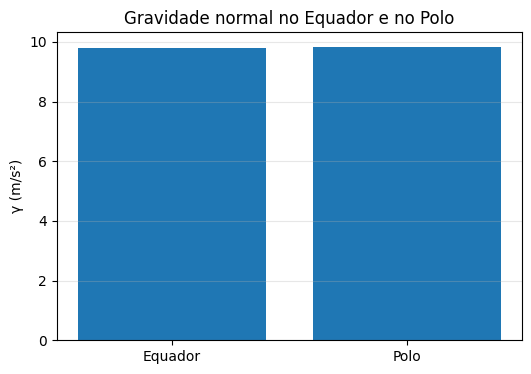

In [4]:
gamma_eq = normal_gravity.normal_gravity_somigliana(0.0)
gamma_pole = normal_gravity.normal_gravity_somigliana(90.0)

diff_si = gamma_pole - gamma_eq
diff_mgal = diff_si * constants.SI_TO_MGAL

print("γ Equador:", gamma_eq, "m/s²")
print("γ Polo:", gamma_pole, "m/s²")
print("Diferença:", diff_si, "m/s²")
print("Diferença:", diff_mgal, "mGal")

plt.figure(figsize=(6, 4))
plt.bar(["Equador", "Polo"], [gamma_eq, gamma_pole])
plt.ylabel("γ (m/s²)")
plt.title("Gravidade normal no Equador e no Polo")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 3. Gradiente de ar livre


In [5]:
grad_si = normal_gravity.free_air_gradient_si()
grad_mgal = normal_gravity.free_air_gradient_mgal_per_m()

print("Gradiente SI:", grad_si, "s^-2 ou m/s² por metro")
print("Gradiente mGal/m:", grad_mgal)
print("Correção para 100 m:", grad_mgal * 100, "mGal")
print("Correção para 1000 m:", grad_mgal * 1000, "mGal")


Gradiente SI: 3.086e-06 s^-2 ou m/s² por metro
Gradiente mGal/m: 0.30860000000000004
Correção para 100 m: 30.860000000000003 mGal
Correção para 1000 m: 308.6 mGal


## 4. Gravidade normal com altura


Latitude: -3.2
γ(h=0): 9.780486221628113
γ(h=5000m): 9.765056221628113
Diferença mGal: 1543.0000000000277


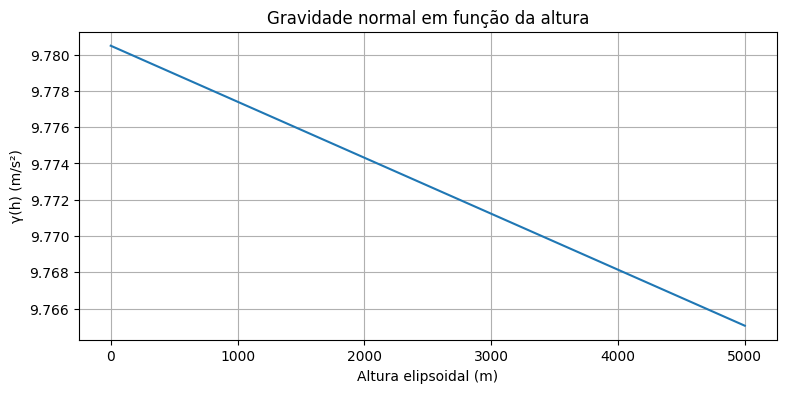

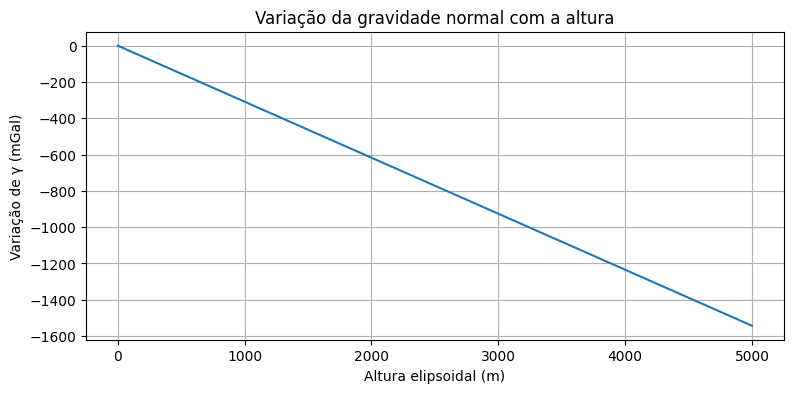

In [6]:
lat0 = -3.2
heights = np.linspace(0, 5000, 101)
gamma_h = normal_gravity.normal_gravity_height(lat0, heights)

print("Latitude:", lat0)
print("γ(h=0):", gamma_h[0])
print("γ(h=5000m):", gamma_h[-1])
print("Diferença mGal:", (gamma_h[0] - gamma_h[-1]) * constants.SI_TO_MGAL)

plt.figure(figsize=(9, 4))
plt.plot(heights, gamma_h)
plt.xlabel("Altura elipsoidal (m)")
plt.ylabel("γ(h) (m/s²)")
plt.title("Gravidade normal em função da altura")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(heights, (gamma_h - gamma_h[0]) * constants.SI_TO_MGAL)
plt.xlabel("Altura elipsoidal (m)")
plt.ylabel("Variação de γ (mGal)")
plt.title("Variação da gravidade normal com a altura")
plt.grid(True)
plt.show()


## 5. Gravidade normal em malha latitude-altura


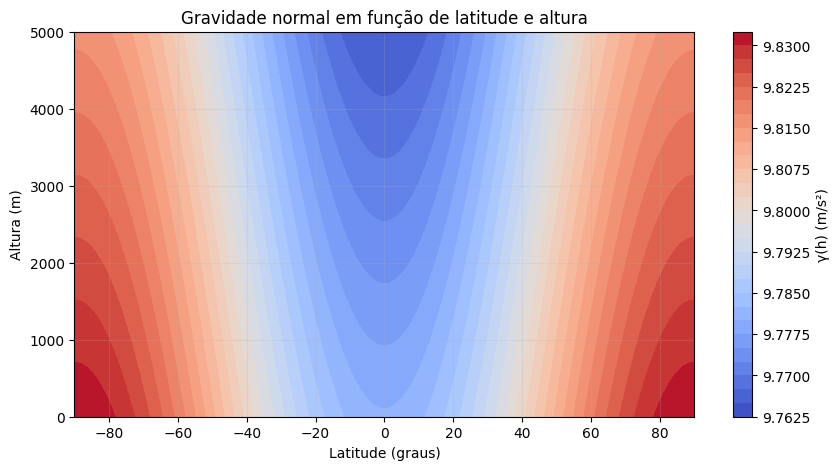

In [8]:
lat_grid = np.linspace(-90, 90, 181)
h_grid = np.linspace(0, 5000, 101)

LAT, H = np.meshgrid(lat_grid, h_grid)
GAMMA_GRID = normal_gravity.normal_gravity_height(LAT, H)

plt.figure(figsize=(10, 5))
c = plt.contourf(LAT, H, GAMMA_GRID, cmap="coolwarm", levels=30)
plt.colorbar(c, label="γ(h) (m/s²)")
plt.xlabel("Latitude (graus)")
plt.ylabel("Altura (m)")
plt.title("Gravidade normal em função de latitude e altura")
plt.grid(alpha=0.2)
plt.show()


## 6. Aceleração centrífuga


Aceleração centrífuga no Equador: 0.033915705976976976 m/s²
Aceleração centrífuga em 45°: 0.023982025685049542 m/s²
Aceleração centrífuga no Polo: 2.0767380382763803e-18 m/s²


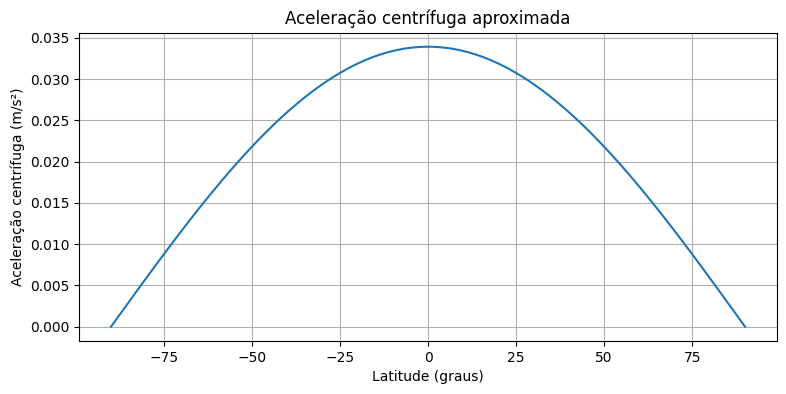

In [9]:
lat = np.linspace(-90, 90, 361)
ac = normal_gravity.centrifugal_acceleration(lat)

print("Aceleração centrífuga no Equador:", normal_gravity.centrifugal_acceleration(0.0), "m/s²")
print("Aceleração centrífuga em 45°:", normal_gravity.centrifugal_acceleration(45.0), "m/s²")
print("Aceleração centrífuga no Polo:", normal_gravity.centrifugal_acceleration(90.0), "m/s²")

plt.figure(figsize=(9, 4))
plt.plot(lat, ac)
plt.xlabel("Latitude (graus)")
plt.ylabel("Aceleração centrífuga (m/s²)")
plt.title("Aceleração centrífuga aproximada")
plt.grid(True)
plt.show()


## 7. Potencial centrífugo


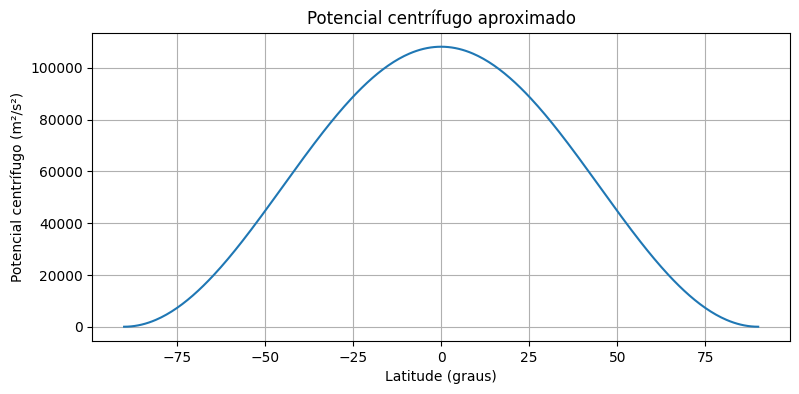

Potencial centrífugo no Equador: 108159.509586439
Potencial centrífugo no Polo: 4.055332064754272e-28


In [10]:
phi_c = normal_gravity.centrifugal_potential(lat)

plt.figure(figsize=(9, 4))
plt.plot(lat, phi_c)
plt.xlabel("Latitude (graus)")
plt.ylabel("Potencial centrífugo (m²/s²)")
plt.title("Potencial centrífugo aproximado")
plt.grid(True)
plt.show()

print("Potencial centrífugo no Equador:", normal_gravity.centrifugal_potential(0.0))
print("Potencial centrífugo no Polo:", normal_gravity.centrifugal_potential(90.0))


## 8. Potencial normal esférico aproximado


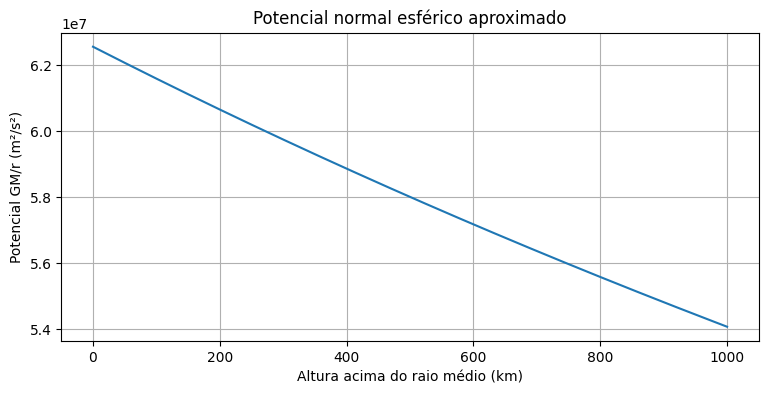

Potencial na superfície média: 62564729.43499937
Potencial a 1000 km: 54076782.78718104


In [11]:
r_values = np.linspace(constants.MEAN_EARTH_RADIUS, constants.MEAN_EARTH_RADIUS + 1000000, 200)
U = normal_gravity.normal_potential_spherical(r_values)

plt.figure(figsize=(9, 4))
plt.plot((r_values - constants.MEAN_EARTH_RADIUS)/1000, U)
plt.xlabel("Altura acima do raio médio (km)")
plt.ylabel("Potencial GM/r (m²/s²)")
plt.title("Potencial normal esférico aproximado")
plt.grid(True)
plt.show()

print("Potencial na superfície média:", U[0])
print("Potencial a 1000 km:", U[-1])


## 9. Comparação entre gravidade normal e gravidade teórica


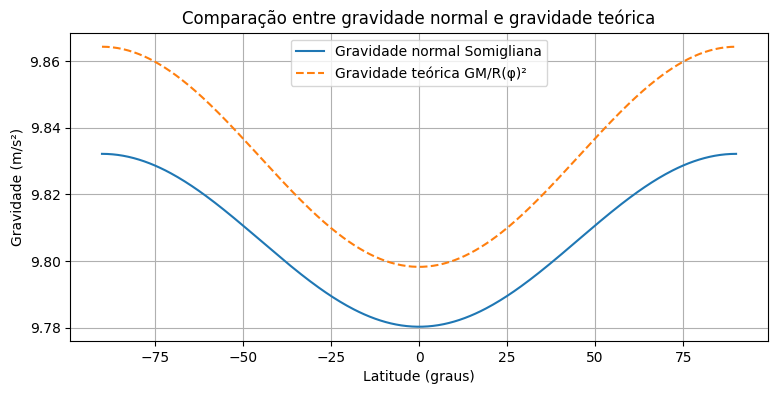

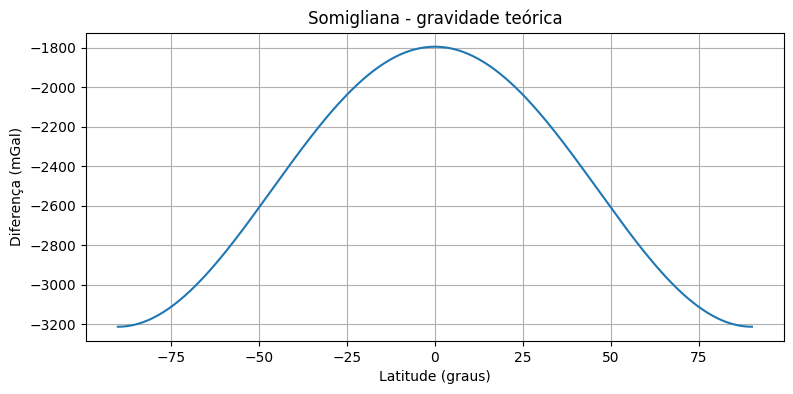

In [12]:
lat = np.linspace(-90, 90, 361)

R_geo = ellipsoid.geocentric_radius(lat)
g_theoretical = constants.WGS84_GM / R_geo**2
gamma_ell = normal_gravity.normal_gravity_somigliana(lat)
diff = (gamma_ell - g_theoretical) * constants.SI_TO_MGAL

plt.figure(figsize=(9, 4))
plt.plot(lat, gamma_ell, label="Gravidade normal Somigliana")
plt.plot(lat, g_theoretical, linestyle="--", label="Gravidade teórica GM/R(φ)²")
plt.xlabel("Latitude (graus)")
plt.ylabel("Gravidade (m/s²)")
plt.title("Comparação entre gravidade normal e gravidade teórica")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(lat, diff)
plt.xlabel("Latitude (graus)")
plt.ylabel("Diferença (mGal)")
plt.title("Somigliana - gravidade teórica")
plt.grid(True)
plt.show()


## 10. Histograma da gravidade normal global


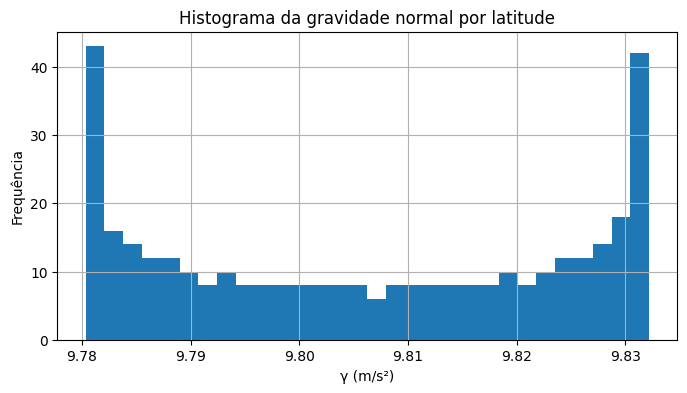

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(gamma_lat, bins=30)
plt.xlabel("γ (m/s²)")
plt.ylabel("Frequência")
plt.title("Histograma da gravidade normal por latitude")
plt.grid(True)
plt.show()


## 11. Cálculo da grade global com passo de 0.5 grau

Nesta seção, calculamos:

- gravidade normal global;
- gravidade teórica global;
- diferença entre ambas.

Essas variáveis serão usadas **nas últimas células** para os mapas em Cartopy com `contourf`.


In [15]:
# ============================================================
# 11. GRADE GLOBAL (STEP = 0.5 GRAU)
# ============================================================

lon_global = np.arange(-180.0, 180.0 + 0.5, 0.5)
lat_global = np.arange(-90.0, 90.0 + 0.5, 0.5)

LON, LAT = np.meshgrid(lon_global, lat_global)

# Gravidade normal no elipsoide
G_NORMAL = normal_gravity.normal_gravity_somigliana(LAT)

# Gravidade teórica esférica calculada com base no raio geocêntrico
R_GEO = ellipsoid.geocentric_radius(LAT)
G_THEORETICAL = constants.WGS84_GM / R_GEO**2

# Diferença em mGal
G_DIFF_MGAL = (G_NORMAL - G_THEORETICAL) * constants.SI_TO_MGAL

print("Shape da grade:", LON.shape)
print("Min/Max gravidade normal:", np.nanmin(G_NORMAL), np.nanmax(G_NORMAL))
print("Min/Max gravidade teórica:", np.nanmin(G_THEORETICAL), np.nanmax(G_THEORETICAL))
print("Min/Max diferença (mGal):", np.nanmin(G_DIFF_MGAL), np.nanmax(G_DIFF_MGAL))


Shape da grade: (361, 721)
Min/Max gravidade normal: 9.7803253359 9.832184937859015
Min/Max gravidade teórica: 9.7982854791873 9.864320992254177
Min/Max diferença (mGal): -3213.605439516165 -1796.014328729889


## 12. Mapa global da gravidade normal com Cartopy

**Esta célula plota a gravidade normal em contorno preenchido (`contourf`).**


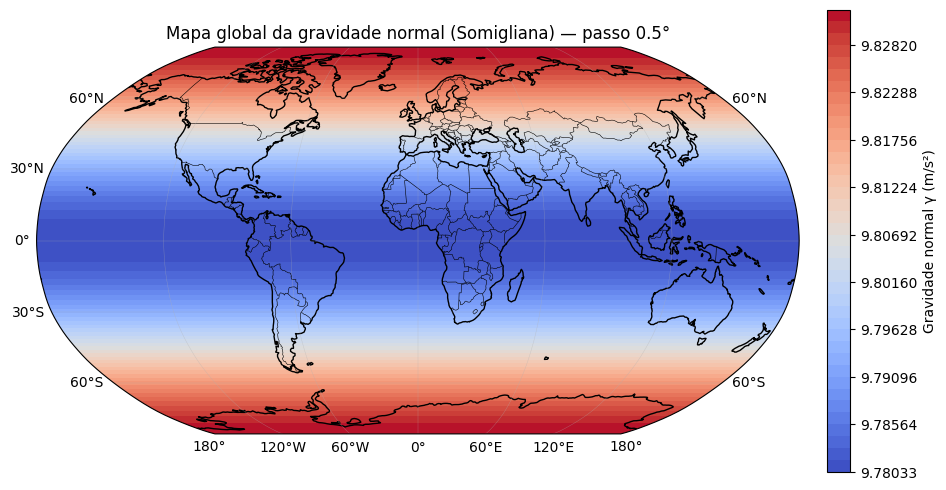

In [17]:
# ============================================================
# 12. MAPA CARTOPY - GRAVIDADE NORMAL
# ============================================================

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())

levels_normal = np.linspace(np.nanmin(G_NORMAL), np.nanmax(G_NORMAL), 40)

cf = ax.contourf(LON, LAT, G_NORMAL, cmap="coolwarm",levels=levels_normal,transform=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.2)
ax.add_feature(cfeature.OCEAN, alpha=0.2)
ax.set_global()
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.03)
cbar.set_label("Gravidade normal γ (m/s²)")

ax.set_title("Mapa global da gravidade normal (Somigliana) — passo 0.5°")
plt.show()


## 13. Mapa global da gravidade teórica com Cartopy

**Esta célula plota a gravidade teórica em contorno preenchido (`contourf`).**


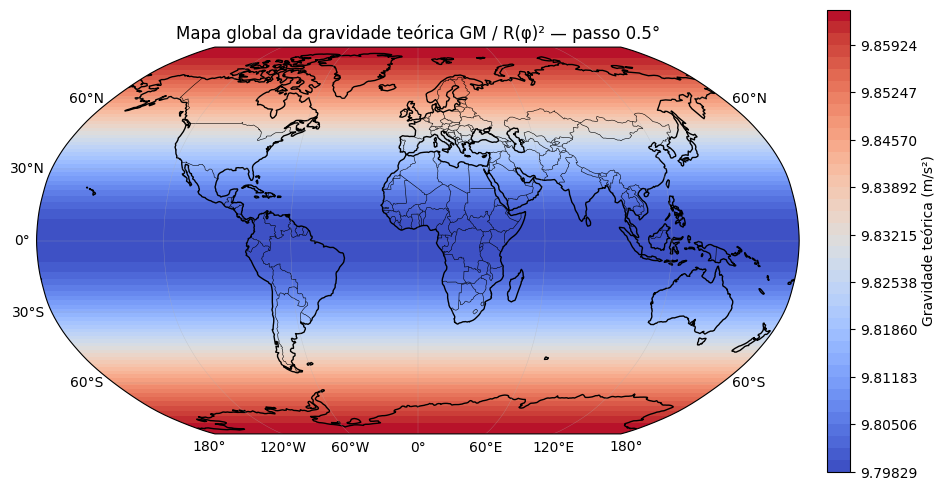

In [18]:
# ============================================================
# 13. MAPA CARTOPY - GRAVIDADE TEÓRICA
# ============================================================

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())

levels_theoretical = np.linspace(np.nanmin(G_THEORETICAL), np.nanmax(G_THEORETICAL), 40)

cf = ax.contourf(LON, LAT, G_THEORETICAL,cmap="coolwarm",levels=levels_theoretical,transform=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.2)
ax.add_feature(cfeature.OCEAN, alpha=0.2)
ax.set_global()
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.03)
cbar.set_label("Gravidade teórica (m/s²)")

ax.set_title("Mapa global da gravidade teórica GM / R(φ)² — passo 0.5°")
plt.show()

## 14. Mapa global da diferença com Cartopy

**Esta célula plota a diferença entre gravidade normal e gravidade teórica em contorno preenchido (`contourf`).**


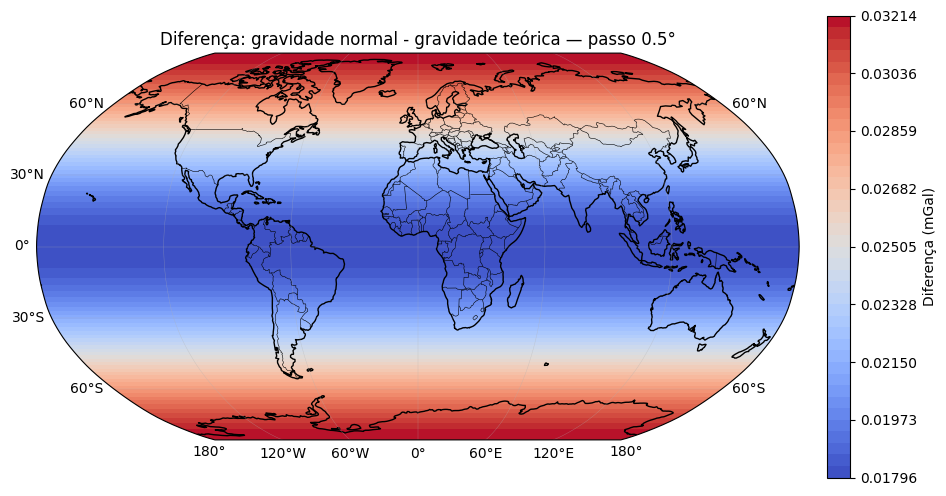

In [22]:
# ============================================================
# 14. MAPA CARTOPY - DIFERENÇA
# ============================================================

G_DIFF_MGAL = G_THEORETICAL-G_NORMAL

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())

#vmax = G_DIFF_MGAL#np.nanmax(np.abs(G_DIFF_MGAL))
levels_diff = np.linspace(G_DIFF_MGAL.min(), G_DIFF_MGAL.max(), 41)

cf = ax.contourf(LON, LAT, G_DIFF_MGAL,levels=levels_diff,transform=ccrs.PlateCarree(),cmap="coolwarm")

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.2)
ax.add_feature(cfeature.OCEAN, alpha=0.2)
ax.set_global()
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.03)
cbar.set_label("Diferença (mGal)")

ax.set_title("Diferença: gravidade normal - gravidade teórica — passo 0.5°")
plt.show()

## 15. Subplots lado a lado com Cartopy

Aqui os dois primeiros mapas aparecem lado a lado para comparação direta.


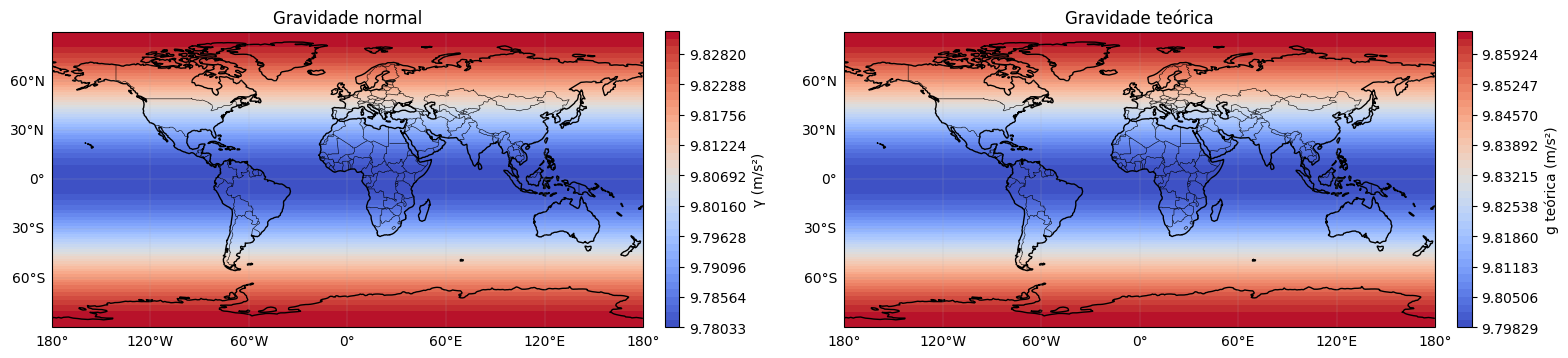

In [35]:
# ============================================================
# 15. SUBPLOTS LADO A LADO
# ============================================================

fig = plt.figure(figsize=(16, 4))

# Gravidade normal
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
cf1 = ax1.contourf(
    LON, LAT, G_NORMAL, cmap="coolwarm",
    levels=np.linspace(np.nanmin(G_NORMAL), np.nanmax(G_NORMAL), 40),
    transform=ccrs.PlateCarree()
)
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linewidth=0.4)
ax1.add_feature(cfeature.LAND, alpha=0.2)
ax1.add_feature(cfeature.OCEAN, alpha=0.2)
ax1.set_global()
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl1.top_labels = False
gl1.right_labels = False
plt.colorbar(cf1, ax=ax1, orientation="vertical", shrink = 0.8, pad=0.03, label="γ (m/s²)")
ax1.set_title("Gravidade normal")

# Gravidade teórica
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
cf2 = ax2.contourf(
    LON, LAT, G_THEORETICAL, cmap="coolwarm",
    levels=np.linspace(np.nanmin(G_THEORETICAL), np.nanmax(G_THEORETICAL), 40),
    transform=ccrs.PlateCarree()
)
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linewidth=0.4)
ax2.add_feature(cfeature.LAND, alpha=0.2)
ax2.add_feature(cfeature.OCEAN, alpha=0.2)
ax2.set_global()
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl2.top_labels = False
gl2.right_labels = False
plt.colorbar(cf2, ax=ax2, orientation="vertical", shrink = 0.8, pad=0.03, label="g teórica (m/s²)")
ax2.set_title("Gravidade teórica")

plt.tight_layout()
plt.show()

## 16. Resumo final

Se todas as células foram executadas sem erro, o módulo `normal_gravity.py` está funcionando corretamente.

As **últimas células** deste notebook agora contêm explicitamente os mapas em Cartopy, com `contourf`, para:

- gravidade normal;
- gravidade teórica;
- diferença.
